# Task A

- Name : Vaishnavi Agarwal
- Roll No.: 230150028

# Importing Libraries


In [63]:
from scipy.integrate import trapezoid
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'scipy'

Completing the given fourier series function

In [28]:
def compute_Fourier_Series(x, t, K, T):

    N = len(t)
    dt = t[1] - t[0]
    c = []
    for k in range(-K, K+1):
        integrand = x * np.exp(-1j * 2 * np.pi * k * t / T)
        ck = (1.0/T) * trapezoidal_integral(integrand, t)
        c.append(ck)
    return np.array(c)

Signal reconstruction

In [29]:
def reconstruct_signal(c, t, K, T):
    ks = np.arange(-K, K+1)
    x_hat = np.zeros_like(t, dtype=complex)
    for idx, k in enumerate(ks):
        x_hat += c[idx] * np.exp(1j * 2 * np.pi * k * t / T)
    return x_hat.real

# **(a) Exploring Polynomial Structures with Fourier Series**

- Chebyshev Polynomial T5(t)

In [40]:
def chebyshev_t(x, n):
  if n == 0:
      return 1
  elif n == 1:
      return x
  else:
      return 2 * x * chebyshev_t(x, n-1) - chebyshev_t(x, n-2)

t = np.linspace(-1, 1, 2000)
T = 2  
x = chebyshev_t(t,5)
Ks = [5, 20, 30, 50, 75, 90]
errors = []

# (i) Error as K increases

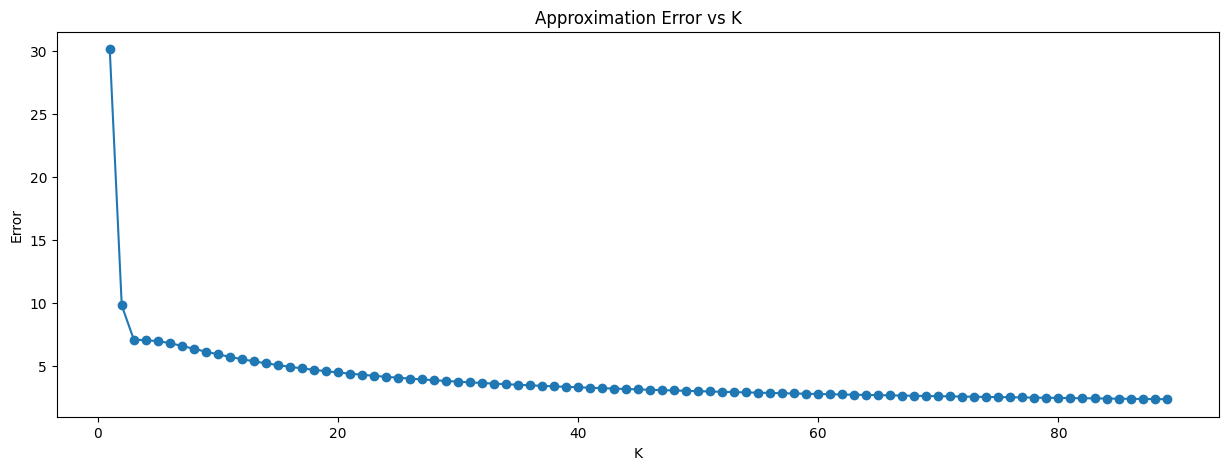

In [41]:

plt.figure(figsize=(15, 5))


K_range = range(1, 90)
for K in K_range:
    c = compute_Fourier_Series(x, t, K, T)
    x_hat = reconstruct_signal(c, t, K, T)
    err = np.linalg.norm(x - x_hat)
    errors.append(err)

plt.plot(K_range, errors, marker='o')
plt.title("Approximation Error vs K")
plt.xlabel("K")
plt.ylabel("Error")
plt.show()

# (ii) Overlay for small vs large K

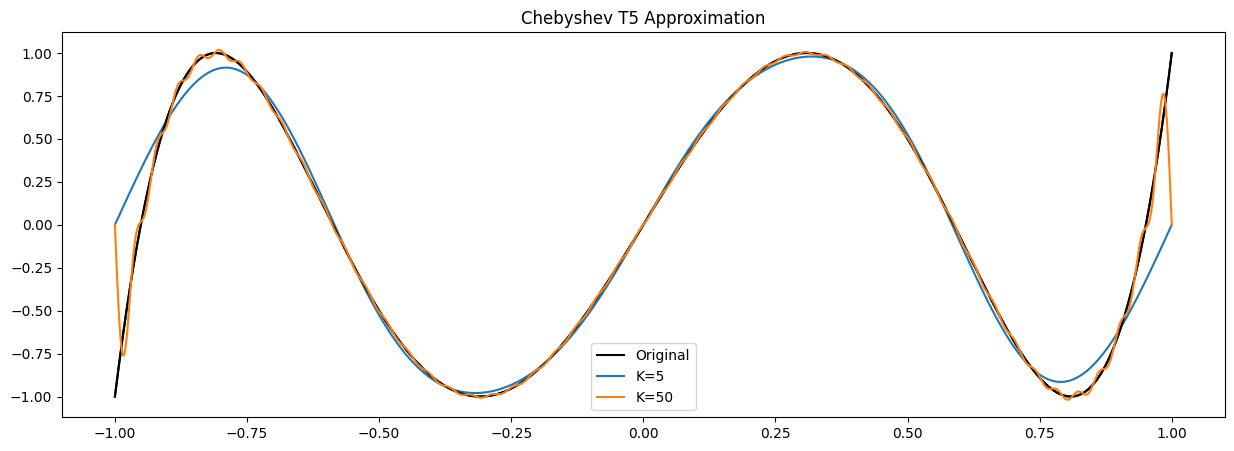

In [43]:
plt.figure(figsize=(15, 5))
for i, K in enumerate([5,50]):
    c = compute_Fourier_Series(x, t, K, T)
    x_hat = reconstruct_signal(c, t, K, T)
   
    plt.plot(t, x, 'k', label="Original" if i == 0 else "")
    plt.plot(t, x_hat, label=f"K={K}")
plt.title("Chebyshev T5 Approximation")
plt.legend()
plt.show()

# (iii) Fourier coefficients spectrum

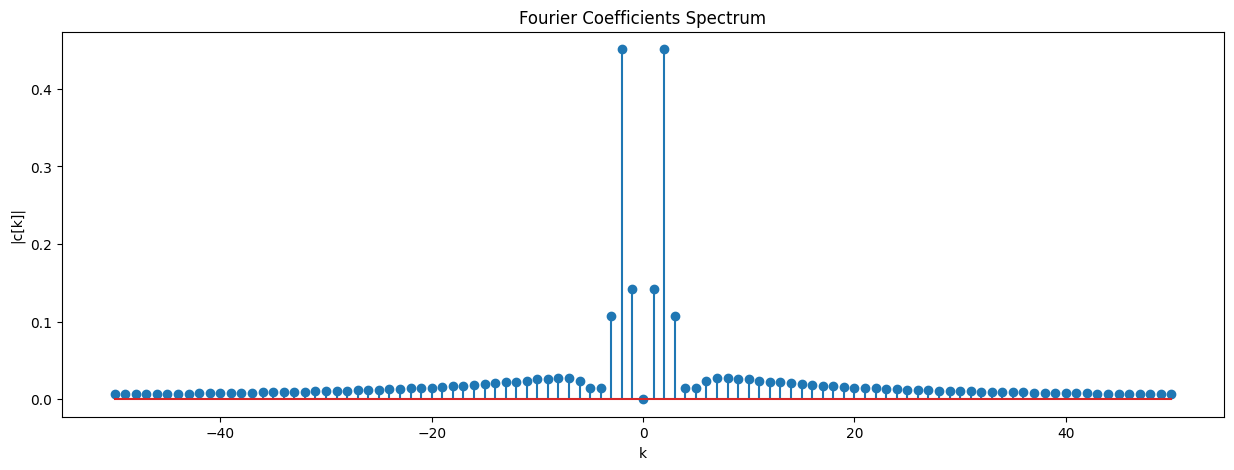

In [45]:
K = 50
c = compute_Fourier_Series(x, t, K, T)
ks = np.arange(-K, K+1)
plt.figure(figsize=(15, 5))
plt.stem(ks, np.abs(c))
plt.title("Fourier Coefficients Spectrum")
plt.xlabel("k")
plt.ylabel("|c[k]|")

plt.show()

# **(b) The Mystery of Gibbs Phenomenon**

In [49]:
def square_pulse(t, p, T):
    t_mod = ((t + T/2) % T) - T/2
    x = np.where(np.abs(t_mod) < p/2, 1.0, 0.0)
    return x

In [51]:
T = 1
t = np.linspace(-0.5, 0.5, 2000)
p = 1.0
x = square_pulse(t,p,T)
print(x[:10])



[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]



=== Fourier Approximation with K = 5 ===
Fourier coefficients c[k]:
[ 5.00250125e-04+1.03321079e-17j -5.00250125e-04+2.34763652e-17j
  5.00250125e-04+8.46821189e-17j -5.00250125e-04-2.25687482e-16j
  5.00250125e-04-1.15991527e-16j  9.99499750e-01+0.00000000e+00j
  5.00250125e-04+1.15991527e-16j -5.00250125e-04+2.25687482e-16j
  5.00250125e-04-8.46821189e-17j -5.00250125e-04-2.34763652e-17j
  5.00250125e-04-1.03321079e-17j]
First 10 reconstructed values:
[0.99449725 0.99449752 0.99449834 0.99449969 0.9945016  0.99450404
 0.99450703 0.99451056 0.99451463 0.99451924]


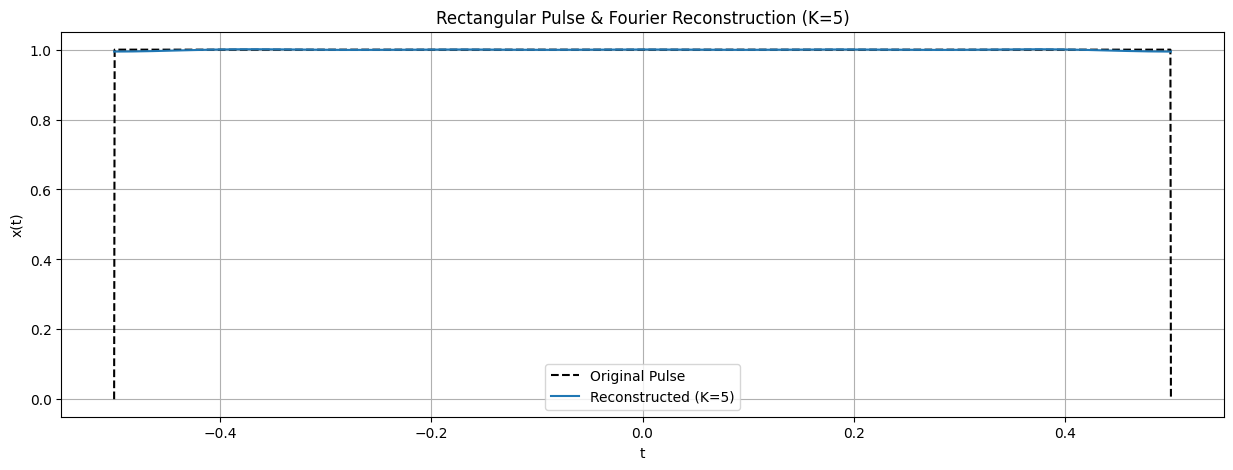


=== Fourier Approximation with K = 50 ===
Fourier coefficients c[k]:
[-5.00250125e-04+5.23805175e-18j  5.00250125e-04-2.36423836e-17j
 -5.00250125e-04+2.28902184e-17j  5.00250125e-04-2.78165620e-17j
 -5.00250125e-04-3.07777892e-17j  5.00250125e-04+3.37457926e-18j
 -5.00250125e-04-2.53432258e-17j  5.00250125e-04+2.62038113e-17j
 -5.00250125e-04-5.06796753e-17j  5.00250125e-04-2.13113490e-17j
 -5.00250125e-04+3.67070198e-17j  5.00250125e-04+9.32413868e-18j
 -5.00250125e-04-1.33963343e-16j  5.00250125e-04-3.00696696e-17j
 -5.00250125e-04-1.01034090e-17j  5.00250125e-04-1.49992594e-17j
 -5.00250125e-04+3.61005442e-17j  5.00250125e-04+3.16620916e-17j
 -5.00250125e-04-5.34647196e-18j  5.00250125e-04-1.17906986e-18j
 -5.00250125e-04-7.87063015e-18j  5.00250125e-04-3.17027491e-17j
 -5.00250125e-04-1.72286501e-17j  5.00250125e-04+2.03491195e-17j
 -5.00250125e-04-2.02440874e-17j  5.00250125e-04-9.50709780e-18j
 -5.00250125e-04-2.94428652e-17j  5.00250125e-04+2.30291318e-17j
 -5.00250125e-04-6.1

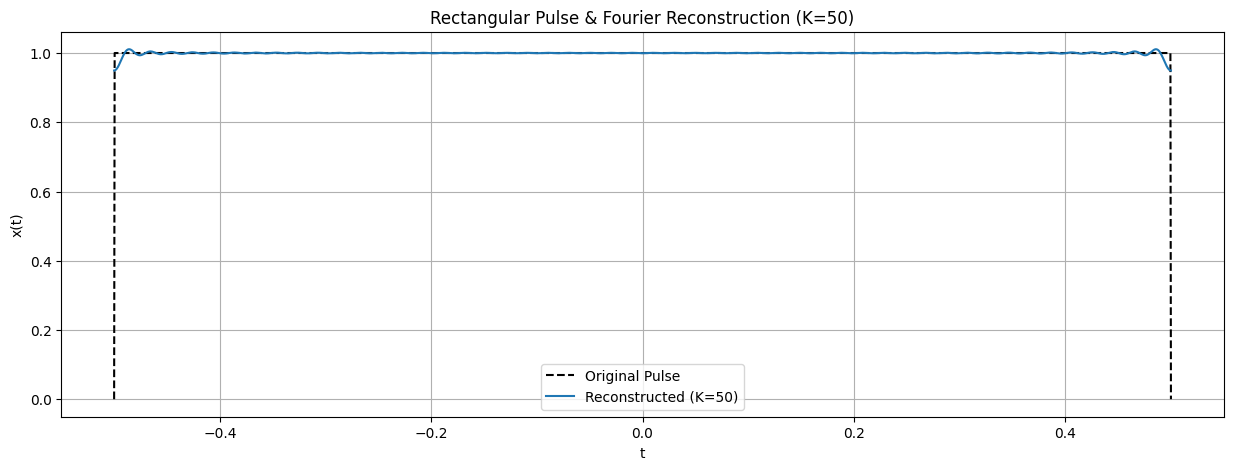


=== Fourier Approximation with K = 100 ===
Fourier coefficients c[k]:
[-5.00250125e-04+9.34311222e-17j  5.00250125e-04-8.69936718e-17j
 -5.00250125e-04+2.06540514e-17j  5.00250125e-04+3.27293531e-17j
 -5.00250125e-04+1.22569056e-16j  5.00250125e-04+6.27753058e-17j
 -5.00250125e-04-2.90159606e-17j  5.00250125e-04+1.39225111e-16j
 -5.00250125e-04-2.37169225e-18j  5.00250125e-04+6.09186096e-16j
 -5.00250125e-04+7.09610322e-17j  5.00250125e-04-6.64073831e-18j
 -5.00250125e-04-4.61328024e-17j  5.00250125e-04-7.43085064e-17j
 -5.00250125e-04+7.80625564e-18j  5.00250125e-04-1.04354459e-18j
 -5.00250125e-04-9.52742659e-18j  5.00250125e-04-7.92822839e-18j
 -5.00250125e-04+3.23905399e-17j  5.00250125e-04+1.68051337e-18j
 -5.00250125e-04-9.82558219e-18j  5.00250125e-04+6.28837260e-18j
 -5.00250125e-04+1.36880524e-18j  5.00250125e-04-6.69833655e-17j
 -5.00250125e-04-1.31188463e-17j  5.00250125e-04-1.46299531e-17j
 -5.00250125e-04-3.43827614e-17j  5.00250125e-04+2.87110288e-17j
 -5.00250125e-04-2.

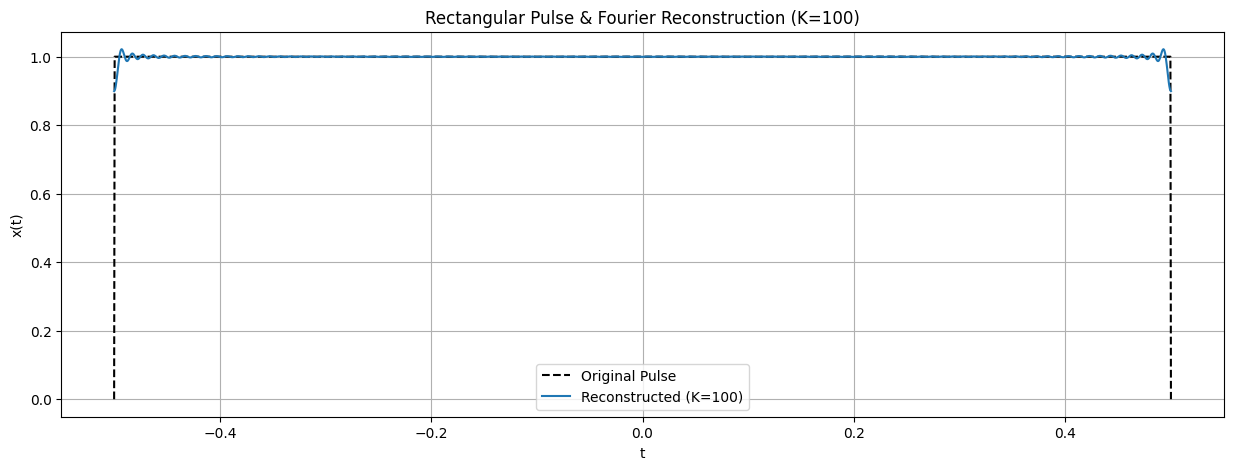

In [62]:
for K in [5, 50, 100]:
    print(f"\n=== Fourier Approximation with K = {K} ===")
    
    # Fourier coefficients
    c = compute_Fourier_Series(x, t, K, T)
    print("Fourier coefficients c[k]:")
    print(c)
    
    # Reconstructed signal
    x_hat = reconstruct_signal(c, t, K, T)
    print("First 10 reconstructed values:")
    print(x_hat[:10])
    
    # Plot
    plt.figure(figsize=(15,5))
    plt.plot(t, x, 'k--', label="Original Pulse")
    plt.plot(t, x_hat, label=f"Reconstructed (K={K})")
    plt.title(f"Rectangular Pulse & Fourier Reconstruction (K={K})")
    plt.xlabel("t")
    plt.ylabel("x(t)")
    plt.legend()
    plt.grid(True)
    plt.show()